In [2]:
from typing import Dict, Any

# =========================
# 1. Caption builder from your metadata dict
# =========================
def meta_to_caption(meta: Dict[str, Any]) -> str:
    country = meta.get("country", "Unknown")
    region  = meta.get("region",  "Unknown")
    lat = meta.get("lat", None)
    lon = meta.get("lon", None)
    lcd = meta.get("landcover_distribution", {})
    # Keep concise. Include top 3 land covers by percentage.
    top = sorted(lcd.items(), key=lambda kv: kv[1], reverse=True)[:3]
    top_str = ", ".join([f"{k} {v:.1f}%" for k, v in top]) if top else "no landcover stats"
    if lat is not None and lon is not None:
        return f"Satellite tile over {region}, {country} at {lat:.4f},{lon:.4f}. Dominant cover: {top_str}."
    return f"Satellite tile over {region}, {country}. Dominant cover: {top_str}."


# Example usage
meta = {
    'country': 'Bangladesh',
    'region': 'Dhaka',
    'lat': 23.1997,
    'lon': 90.1644,
    'landcover_distribution': {
        'Tree cover': 39.27,
        'Shrubland': 0.01,
        'Grassland': 1.22,
        'Cropland': 52.58,
        'Built-up': 0.27,
        'Bare / sparse vegetation': 0.52,
        'Permanent water bodies': 3.43,
        'Herbaceous wetland': 2.7
    }
}

print(meta_to_caption(meta))

Satellite tile over Dhaka, Bangladesh at 23.1997,90.1644. Dominant cover: Cropland 52.6%, Tree cover 39.3%, Permanent water bodies 3.4%.


In [11]:
# Contrastive learning between satellite images and metadata captions
# Image encoder: DINOv3 ViT-L/16 (CLS token)
# Text encoder: RoBERTa-base (HF) with projection head

import os, ast, json, math, random
from typing import Dict, Any, List, Tuple
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as T
from transformers import AutoTokenizer, AutoModel


# =========================
# 0) Paths
# =========================
IMAGE_META_SPECS = [
    # Uttar Pradesh
    ("/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/data/iclr_2026_processed_data/final_data/uttar_pradesh/train/images",
     "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/Foundation-Models/metadata_extractor/output/uttar_pradesh_train_metadata.txt"),
    ("/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/data/iclr_2026_processed_data/final_data/uttar_pradesh/val/images",
     "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/Foundation-Models/metadata_extractor/output/uttar_pradesh_val_metadata.txt"),
    # Pakistan Punjab
    ("/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/data/iclr_2026_processed_data/final_data/pak_punjab/train/images",
     "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/Foundation-Models/metadata_extractor/output/pak_punjab_train_metadata.txt"),
    ("/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/data/iclr_2026_processed_data/final_data/pak_punjab/val/images",
     "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/Foundation-Models/metadata_extractor/output/pak_punjab_val_metadata.txt"),
    # Bangladesh
    ("/home/rishabh.mondal/Brick-Kilns-project/ijcai_2026_processed_data/final_data/bangladesh/train/images",
     "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/Foundation-Models/metadata_extractor/output/bangladesh_train_metadata.txt"),
    ("/home/rishabh.mondal/Brick-Kilns-project/ijcai_2026_processed_data/final_data/bangladesh/val/images",
     "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/Foundation-Models/metadata_extractor/output/bangladesh_val_metadata.txt"),
]

# DINO model and weights
MODEL_NAME = "dinov3_vitl16"
DINO_WEIGHTS = "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/Foundation-Models/dinov3/dinov3_vitl16_pretrain_sat493m-eadcf0ff.pth"

In [16]:
META_PATH = "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/Foundation-Models/metadata_extractor/output/uttar_pradesh_train_metadata.txt"


In [14]:
def load_metadata_lines(path):
    items = []
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                fname, meta_str = line.split("\t", 1)
                meta = ast.literal_eval(meta_str)
                items.append((fname, meta))
            except Exception as e:
                print("Skipping line due to error:", e)
    return items

In [13]:

# =========================
# 1) Caption builder
# =========================
def meta_to_caption(meta: Dict[str, Any]) -> str:
    country = meta.get("country", "Unknown")
    region  = meta.get("region", "Unknown")
    lat = meta.get("lat", None)
    lon = meta.get("lon", None)
    lcd = meta.get("landcover_distribution", {})

    sorted_lc = sorted(lcd.items(), key=lambda kv: kv[1], reverse=True)
    top3 = sorted_lc[:3]
    others = sorted_lc[3:]

    top_str = ", ".join([f"{k} {v:.1f}%" for k, v in top3]) if top3 else "no landcover stats"
    others_str = ", ".join([f"{k} {v:.1f}%" for k, v in others])

    caption = f"Satellite tile over {region}, {country}"
    if lat is not None and lon is not None:
        caption += f" at {lat:.4f}, {lon:.4f}"
    caption += f". Dominant land cover: {top_str}"
    if others_str:
        caption += f"; minor classes: {others_str}"
    caption += "."
    return caption

In [17]:
if __name__ == "__main__":
    records = load_metadata_lines(META_PATH)
    print(f"Total metadata entries: {len(records)}")

    if len(records) > 0:
        fname, meta = records[0]
        print("Example filename:", fname)
        print("Metadata dict:", meta)
        print("Generated caption:")
        print(meta_to_caption(meta))

Skipping line due to error: malformed node or string on line 1: <ast.Name object at 0x7ff7616b21d0>
Total metadata entries: 9122
Example filename: 27.7644_80.2397.png
Metadata dict: {'country': 'India', 'region': 'Uttar Pradesh', 'lat': 27.7644, 'lon': 80.2397, 'landcover_distribution': {'Tree cover': 6.05, 'Grassland': 12.85, 'Cropland': 79.13, 'Built-up': 1.24, 'Bare / sparse vegetation': 0.73}}
Generated caption:
Satellite tile over Uttar Pradesh, India at 27.7644, 80.2397. Dominant land cover: Cropland 79.1%, Grassland 12.8%, Tree cover 6.0%; minor classes: Built-up 1.2%, Bare / sparse vegetation 0.7%.


In [23]:



# =========================
# 2) Metadata file loader (TSV: filename<TAB>{python_dict})
# =========================
def load_meta_tsv(path: str) -> Dict[str, Dict[str, Any]]:
    mp = {}
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            # split once on tab; right side is a python dict string
            try:
                fname, meta_str = line.split("\t", 1)
            except ValueError:
                continue
            meta = ast.literal_eval(meta_str)
            mp[fname] = meta
    return mp

def merge_meta_maps(specs: List[Tuple[str,str]]) -> Tuple[List[Tuple[str,str]], Dict[str,Dict[str,Any]]]:
    # Return a list of (image_dir, fname) pairs and a global metadata map by fname
    pairs = []
    global_meta = {}
    for img_dir, meta_path in specs:
        if not os.path.isdir(img_dir) or not os.path.isfile(meta_path):
            continue
        meta_map = load_meta_tsv(meta_path)
        for fname in os.listdir(img_dir):
            if not fname.lower().endswith((".png", ".jpg", ".jpeg")):
                continue
            if fname in meta_map:
                pairs.append((img_dir, fname))
                global_meta[fname] = meta_map[fname]
    return pairs, global_meta

In [24]:
if __name__ == "__main__":
    IMAGE_META_SPECS = [
        ("/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/data/iclr_2026_processed_data/final_data/uttar_pradesh/train/images",
         "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/Foundation-Models/metadata_extractor/output/uttar_pradesh_train_metadata.txt")
    ]

    img_path, fname, meta = merge_meta_maps(IMAGE_META_SPECS)
    print("Selected image:", img_path)
    print("Filename:", fname)
    print("Metadata dictionary:", meta)

ValueError: malformed node or string on line 1: <ast.Name object at 0x7ff7554eeb90>

In [25]:
import os, ast, json, re
from typing import Dict, Any, List, Tuple, Optional

def _parse_meta(meta_str: str) -> Optional[Dict[str, Any]]:
    # Try Python-literal dict
    try:
        return ast.literal_eval(meta_str)
    except Exception:
        pass
    # Try JSON by converting single quotes to double quotes (rough fallback)
    try:
        meta_jsonish = re.sub(r"(?<!\\)'", '"', meta_str)
        return json.loads(meta_jsonish)
    except Exception:
        return None

def load_meta_tsv_robust(path: str) -> Dict[str, Dict[str, Any]]:
    mp: Dict[str, Dict[str, Any]] = {}
    bad = 0
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if "\t" not in line:
                bad += 1
                continue
            fname, meta_str = line.split("\t", 1)
            meta = _parse_meta(meta_str)
            if isinstance(meta, dict):
                mp[fname] = meta
            else:
                bad += 1
    if bad:
        print(f"[load_meta_tsv_robust] skipped {bad} malformed lines")
    return mp

def merge_one_sample(specs: List[Tuple[str, str]]) -> Tuple[str, str, Dict[str, Any]]:
    """
    Return exactly one (image_path, filename, metadata_dict).
    """
    for img_dir, meta_path in specs:
        if not os.path.isdir(img_dir) or not os.path.isfile(meta_path):
            continue
        meta_map = load_meta_tsv_robust(meta_path)
        # Find first image that has metadata
        for fname in os.listdir(img_dir):
            if not fname.lower().endswith((".png", ".jpg", ".jpeg")):
                continue
            if fname in meta_map:
                return os.path.join(img_dir, fname), fname, meta_map[fname]
    raise RuntimeError("No matching (image, metadata) pair found")

# Optional: your caption builder to verify the parsed dict
def meta_to_caption(meta: Dict[str, Any]) -> str:
    country = meta.get("country", "Unknown")
    region  = meta.get("region", "Unknown")
    lat = meta.get("lat", None)
    lon = meta.get("lon", None)
    lcd = meta.get("landcover_distribution", {})
    sorted_lc = sorted(lcd.items(), key=lambda kv: kv[1], reverse=True)
    top3 = sorted_lc[:3]
    others = sorted_lc[3:]
    top_str = ", ".join([f"{k} {v:.1f}%" for k, v in top3]) if top3 else "no landcover stats"
    others_str = ", ".join([f"{k} {v:.1f}%" for k, v in others])
    caption = f"Satellite tile over {region}, {country}"
    if lat is not None and lon is not None:
        caption += f" at {lat:.4f}, {lon:.4f}"
    caption += f". Dominant land cover: {top_str}"
    if others_str:
        caption += f"; minor classes: {others_str}"
    caption += "."
    return caption

if __name__ == "__main__":
    IMAGE_META_SPECS = [
        ("/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/data/iclr_2026_processed_data/final_data/uttar_pradesh/train/images",
         "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/Foundation-Models/metadata_extractor/output/uttar_pradesh_train_metadata.txt")
    ]

    img_path, fname, meta = merge_one_sample(IMAGE_META_SPECS)
    print("Selected image:", img_path)
    print("Filename:", fname)
    print("Metadata dict keys:", list(meta.keys()))
    print("Caption:", meta_to_caption(meta))

[load_meta_tsv_robust] skipped 1 malformed lines
Selected image: /home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/data/iclr_2026_processed_data/final_data/uttar_pradesh/train/images/28.1555_81.2661.png
Filename: 28.1555_81.2661.png
Metadata dict keys: ['country', 'region', 'lat', 'lon', 'landcover_distribution']
Caption: Satellite tile over Uttar Pradesh, India at 28.1555, 81.2661. Dominant land cover: Tree cover 99.8%, Shrubland 0.1%, Cropland 0.0%.


In [26]:


# =========================
# 3) Dataset
# =========================
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

class RSCaptionDataset(Dataset):
    def __init__(self, pairs: List[Tuple[str,str]], meta_map: Dict[str,Dict[str,Any]], size=800):
        self.pairs = pairs
        self.meta_map = meta_map
        self.tf = T.Compose([
            T.Resize(size),
            T.CenterCrop(size),
            T.ToTensor(),
            T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ])

    def __len__(self): return len(self.pairs)

    def __getitem__(self, idx):
        img_dir, fname = self.pairs[idx]
        path = os.path.join(img_dir, fname)
        img = Image.open(path).convert("RGB")
        x = self.tf(img)
        cap = meta_to_caption(self.meta_map[fname])
        return {"image": x, "caption": cap, "fname": fname}

[load_meta_tsv_robust] skipped 1 malformed lines
Loaded sample:
  path = /home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/data/iclr_2026_processed_data/final_data/uttar_pradesh/train/images/28.1555_81.2661.png
  file = 28.1555_81.2661.png

Generated caption:
 Satellite tile over Uttar Pradesh, India at 28.1555, 81.2661. Dominant land cover: Tree cover 99.8%, Shrubland 0.1%, Cropland 0.0%. 

Dataset sample keys: dict_keys(['image', 'caption', 'fname'])
Dataset sample values: {'image': tensor([[[-1.8097, -1.8097, -1.8097,  ..., -1.1589, -1.1589, -1.1589],
         [-1.8097, -1.8097, -1.8097,  ..., -1.1589, -1.1589, -1.1589],
         [-1.8097, -1.8097, -1.8097,  ..., -1.1589, -1.1589, -1.1589],
         ...,
         [-1.5185, -1.5185, -1.5185,  ..., -1.1247, -1.1247, -1.1247],
         [-1.5185, -1.5185, -1.5185,  ..., -1.1247, -1.1247, -1.1247],
         [-1.5185, -1.5185, -1.5185,  ..., -1.1247, -1.1247, -1.1247]],

        [[-1.0378, -1.0378, -1.0378,  ..., -0.7577, -0.7577,

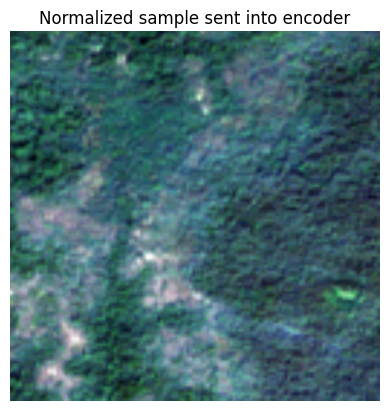

In [30]:
import torch
from torch.utils.data import DataLoader
from torchvision import transforms as T
from PIL import Image
import matplotlib.pyplot as plt

# assume meta_to_caption, RSCaptionDataset, and IMAGENET_MEAN/STD already defined
# also reuse merge_one_sample from the previous message

if __name__ == "__main__":
    IMAGE_META_SPECS = [
        ("/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/data/iclr_2026_processed_data/final_data/uttar_pradesh/train/images",
         "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/Foundation-Models/metadata_extractor/output/uttar_pradesh_train_metadata.txt")
    ]

    # load a single (image, metadata)
    img_path, fname, meta = merge_one_sample(IMAGE_META_SPECS)
    print(f"Loaded sample:\n  path = {img_path}\n  file = {fname}\n")

    # verify caption
    caption = meta_to_caption(meta)
    print("Generated caption:\n", caption, "\n")

    # build dataset just for this one sample
    pairs = [(os.path.dirname(img_path), fname)]
    meta_map = {fname: meta}
    ds = RSCaptionDataset(pairs, meta_map, size=800)
    sample = ds[0]
    print("Dataset sample keys:", sample.keys())
    print("Dataset sample values:", sample
          )

    # inspect each element
    img_tensor = sample["image"]       # [3,800,800]
    print("Image tensor shape:", tuple(img_tensor.shape))
    print("Tensor value range:", (img_tensor.min().item(), img_tensor.max().item()))
    print("Caption text:", sample["caption"])
    print("Filename:", sample["fname"])

    # visualize the preprocessed image (undo normalization)
    inv_norm = T.Normalize(
        mean=[-m/s for m, s in zip(IMAGENET_MEAN, IMAGENET_STD)],
        std=[1/s for s in IMAGENET_STD]
    )
    img_show = inv_norm(img_tensor).clamp(0, 1)
    plt.imshow(img_show.permute(1, 2, 0))
    plt.title("Normalized sample sent into encoder")
    plt.axis("off")
    plt.show()

In [ ]:


# =========================
# 4) Encoders
# =========================
@torch.no_grad()
def get_dino_cls(model, images: torch.Tensor) -> torch.Tensor:
    # images: [B,3,H,W], normalized to ImageNet stats
    # returns CLS from last layer: [B,C]
    out = model.get_intermediate_layers(images, n=1, return_class_token=True)
    # out is a list of length n; each item is (patch_tokens, cls_token)
    cls = out[-1][1]  # [B, C]
    return cls

class DINOImageEncoder(nn.Module):
    def __init__(self, model, proj_dim=512, feat_dim=1024):  # vitl16 CLS dim is typically 1024
        super().__init__()
        self.backbone = model
        self.head = nn.Sequential(
            nn.LayerNorm(feat_dim),
            nn.Linear(feat_dim, proj_dim),
        )

    def forward(self, images):
        cls = get_dino_cls(self.backbone, images)     # [B,C]
        z = self.head(cls)                            # [B,D]
        return F.normalize(z, dim=-1)

class HFTextEncoder(nn.Module):
    # RoBERTa-base is a strong general encoder; you can swap to "allenai/scibert_scivocab_uncased" if you prefer scientific text.
    def __init__(self, name="roberta-base", proj_dim=512, out_dim=768):
        super().__init__()
        self.tok = AutoTokenizer.from_pretrained(name)
        self.lm  = AutoModel.from_pretrained(name)
        self.proj = nn.Linear(out_dim, proj_dim)

    @torch.no_grad()
    def tokenize(self, texts: List[str], max_len=64, device="cpu"):
        enc = self.tok(
            texts,
            padding=True,
            truncation=True,
            max_length=max_len,
            return_tensors="pt"
        )
        return {k: v.to(device) for k, v in enc.items()}

    def forward(self, input_ids, attention_mask):
        out = self.lm(input_ids=input_ids, attention_mask=attention_mask)
        # mean-pool over tokens
        last = out.last_hidden_state                        # [B,T,H]
        mask = attention_mask.unsqueeze(-1).float()         # [B,T,1]
        pooled = (last * mask).sum(dim=1) / mask.sum(dim=1).clamp_min(1e-6)
        z = self.proj(pooled)                               # [B,D]
        return F.normalize(z, dim=-1)

# =========================
# 5) Loss
# =========================
class ClipLoss(nn.Module):
    def __init__(self, init_logit_scale=math.log(1/0.07)):
        super().__init__()
        self.logit_scale = nn.Parameter(torch.tensor(init_logit_scale))

    def forward(self, z_img, z_txt):
        scale = self.logit_scale.exp().clamp(max=100)
        logits_i2t = scale * (z_img @ z_txt.t())
        logits_t2i = logits_i2t.t()
        targets = torch.arange(z_img.size(0), device=z_img.device)
        li2t = F.cross_entropy(logits_i2t, targets)
        lt2i = F.cross_entropy(logits_t2i, targets)
        return 0.5 * (li2t + lt2i)

# =========================
# 6) Model wrapper
# =========================
class RSCLIP(nn.Module):
    def __init__(self, image_encoder, text_encoder):
        super().__init__()
        self.image_enc = image_encoder
        self.text_enc  = text_encoder
        self.criterion = ClipLoss()

    def forward(self, images, input_ids, attention_mask):
        zi = self.image_enc(images)
        zt = self.text_enc(input_ids, attention_mask)
        loss = self.criterion(zi, zt)
        return loss, zi, zt

# =========================
# 7) Build everything
# =========================
def build_loaders(batch_size=16, size=800, num_workers=8):
    pairs, meta_map = merge_meta_maps(IMAGE_META_SPECS)
    ds = RSCaptionDataset(pairs, meta_map, size=size)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
    return loader

def load_dino_vitl16(weights_path: str):
    model = torch.hub.load('facebookresearch/dinov3:main', MODEL_NAME, pretrained=False)
    ckpt = torch.load(weights_path, map_location="cpu")
    # try to be robust to various checkpoint formats
    state = ckpt.get("state_dict", ckpt.get("model", ckpt))
    # strip potential "module." prefixes
    new_state = {k.replace("module.", ""): v for k, v in state.items()}
    missing, unexpected = model.load_state_dict(new_state, strict=False)
    if len(unexpected) > 0:
        print("Unexpected keys:", unexpected)
    if len(missing) > 0:
        print("Missing keys:", missing[:10], "...")
    return model

# =========================
# 8) Training loop (single epoch skeleton)
# =========================
def train_one_epoch(model, dino_enc, txt_enc, loader, device="cuda", lr=1e-4):
    model.to(device).train()
    dino_enc.eval()  # backbone used inside image encoder; we train projection head, not mandatory to freeze dino
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    total = 0.0
    for batch in loader:
        images = batch["image"].to(device, non_blocking=True)
        caps   = batch["caption"]
        tok = txt_enc.tokenize(caps, max_len=64, device=device)

        opt.zero_grad(set_to_none=True)
        loss, _, _ = model(images, tok["input_ids"], tok["attention_mask"])
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        total += loss.item()
    return total / max(1, len(loader))

# =========================
# 9) Main
# =========================
if __name__ == "__main__":
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # data
    loader = build_loaders(batch_size=16, size=800, num_workers=8)

    # encoders
    dino = load_dino_vitl16(DINO_WEIGHTS)
    # vitl16 CLS dim = 1024
    img_enc = DINOImageEncoder(dino, proj_dim=512, feat_dim=1024)
    txt_enc = HFTextEncoder(name="roberta-base", proj_dim=512, out_dim=768)

    model = RSCLIP(img_enc, txt_enc)

    avg_loss = train_one_epoch(model, dino, txt_enc, loader, device=device, lr=1e-4)
    print("avg_loss:", avg_loss)

ValueError: malformed node or string on line 1: <ast.Name object at 0x7ff761b6ac90>

Skipped malformed lines: 1


Using cache found in /home/rishabh.mondal/.cache/torch/hub/facebookresearch_dinov3_main
2025-11-08 04:24:43.082015: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762556083.098402  491064 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762556083.103285  491064 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1762556083.117959  491064 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1762556083.117977  491064 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.

epoch 1 avg_loss 1.895291


epochs: 100%|██████████| 1/1 [03:52<00:00, 232.48s/it]

saved backbone to /home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/Foundation-Models/checkpoints/dino_vitl16_finetuned_epoch1.pth


saved loss plot to /home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/Foundation-Models/checkpoints/loss_curve.png


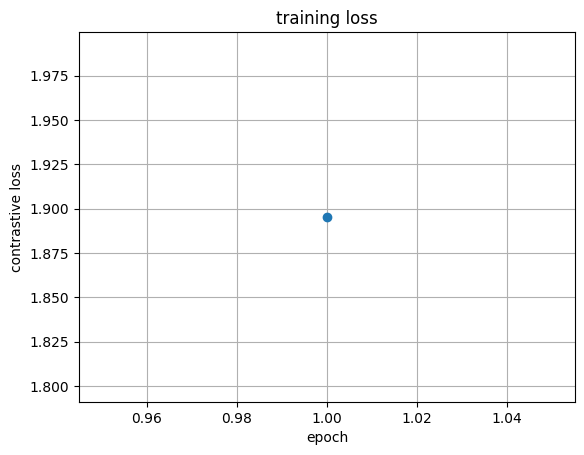

In [ ]:
# Contrastive learning between satellite images and metadata captions
# Image encoder: DINOv3 ViT L 16 (CLS token) fine tuned end to end
# Text encoder: RoBERTa base with projection head
# Saves DINO backbone every 5 epochs and plots loss

import os, ast, json, math, random, re
from typing import Dict, Any, List, Tuple, Optional
from PIL import Image
import matplotlib.pyplot as plt
import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from transformers import AutoTokenizer, AutoModel

# =========================
# config
# =========================
SEED = 42
EPOCHS = 1
BATCH_SIZE = 16
IMG_SIZE = 800
NUM_WORKERS = 8
MODEL_NAME = "dinov3_vitl16"
DINO_WEIGHTS = "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/Foundation-Models/dinov3/dinov3_vitl16_pretrain_sat493m-eadcf0ff.pth"
SAVE_DIR = "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/Foundation-Models/cvpr"
os.makedirs(SAVE_DIR, exist_ok=True)

# learning rates
BACKBONE_LR = 5e-6
HEAD_LR = 1e-4
WEIGHT_DECAY_BACKBONE = 0.05
WEIGHT_DECAY_HEAD = 1e-4

DEVICE = "cuda:1" if torch.cuda.is_available() else "cpu"
AMP = DEVICE == "cuda:1"

# =========================
# paths
# =========================
IMAGE_META_SPECS = [
    # ("/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/data/iclr_2026_processed_data/final_data/uttar_pradesh/train/images",
    #  "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/Foundation-Models/metadata_extractor/output/uttar_pradesh_train_metadata.txt"),
    ("/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/data/iclr_2026_processed_data/final_data/uttar_pradesh/val/images",
     "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/Foundation-Models/metadata_extractor/output/uttar_pradesh_val_metadata.txt"),
    # ("/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/data/iclr_2026_processed_data/final_data/pak_punjab/train/images",
    #  "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/Foundation-Models/metadata_extractor/output/pak_punjab_train_metadata.txt"),
    # ("/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/data/iclr_2026_processed_data/final_data/pak_punjab/val/images",
    #  "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/Foundation-Models/metadata_extractor/output/pak_punjab_val_metadata.txt"),
    # ("/home/rishabh.mondal/Brick-Kilns-project/ijcai_2026_processed_data/final_data/bangladesh/train/images",
    #  "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/Foundation-Models/metadata_extractor/output/bangladesh_train_metadata.txt"),
    # ("/home/rishabh.mondal/Brick-Kilns-project/ijcai_2026_processed_data/final_data/bangladesh/val/images",
    #  "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/Foundation-Models/metadata_extractor/output/bangladesh_val_metadata.txt"),
]

# =========================
# caption builder
# =========================
def meta_to_caption(meta: Dict[str, Any]) -> str:
    country = meta.get("country", "Unknown")
    region  = meta.get("region", "Unknown")
    lat = meta.get("lat", None)
    lon = meta.get("lon", None)
    lcd = meta.get("landcover_distribution", {})

    sorted_lc = sorted(lcd.items(), key=lambda kv: kv[1], reverse=True)
    top3 = sorted_lc[:3]
    others = sorted_lc[3:]

    top_str = ", ".join([f"{k} {v:.1f}%" for k, v in top3]) if top3 else "no landcover stats"
    others_str = ", ".join([f"{k} {v:.1f}%" for k, v in others])

    caption = f"Satellite tile over {region}, {country}"
    if lat is not None and lon is not None:
        caption += f" at {lat:.4f}, {lon:.4f}"
    caption += f". Dominant land cover: {top_str}"
    if others_str:
        caption += f"; minor classes: {others_str}"
    caption += "."
    return caption

# =========================
# metadata loading
# =========================
def _parse_meta(meta_str: str) -> Optional[Dict[str, Any]]:
    try:
        return ast.literal_eval(meta_str)
    except Exception:
        pass
    try:
        meta_jsonish = re.sub(r"(?<!\\)'", '"', meta_str)
        return json.loads(meta_jsonish)
    except Exception:
        return None

def load_meta_tsv(path: str) -> Dict[str, Dict[str, Any]]:
    mp = {}
    bad = 0
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if not line or "\t" not in line:
                bad += 1
                continue
            fname, meta_str = line.split("\t", 1)
            meta = _parse_meta(meta_str)
            if isinstance(meta, dict):
                mp[fname] = meta
            else:
                bad += 1
    if bad:
        print(f"Skipped malformed lines: {bad}")
    return mp

def merge_meta_maps(specs: List[Tuple[str,str]]) -> Tuple[List[Tuple[str,str]], Dict[str,Dict[str,Any]]]:
    pairs = []
    global_meta = {}
    for img_dir, meta_path in specs:
        if not os.path.isdir(img_dir) or not os.path.isfile(meta_path):
            continue
        meta_map = load_meta_tsv(meta_path)
        for fname in os.listdir(img_dir):
            if not fname.lower().endswith((".png", ".jpg", ".jpeg")):
                continue
            if fname in meta_map:
                pairs.append((img_dir, fname))
                global_meta[fname] = meta_map[fname]
    return pairs, global_meta

# =========================
# dataset
# =========================
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

class RSCaptionDataset(Dataset):
    def __init__(self, pairs: List[Tuple[str,str]], meta_map: Dict[str,Dict[str,Any]], size=IMG_SIZE):
        self.pairs = pairs
        self.meta_map = meta_map
        self.tf = T.Compose([
            T.Resize(size),
            T.CenterCrop(size),
            T.ToTensor(),
            T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ])

    def __len__(self): 
        return len(self.pairs)

    def __getitem__(self, idx):
        img_dir, fname = self.pairs[idx]
        path = os.path.join(img_dir, fname)
        img = Image.open(path).convert("RGB")
        x = self.tf(img)
        cap = meta_to_caption(self.meta_map[fname])
        return {"image": x, "caption": cap, "fname": fname}

def build_loader(batch_size=BATCH_SIZE, size=IMG_SIZE, num_workers=NUM_WORKERS):
    pairs, meta_map = merge_meta_maps(IMAGE_META_SPECS)
    ds = RSCaptionDataset(pairs, meta_map, size=size)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
    return loader

# =========================
# encoders
# =========================
def get_dino_cls(model, images: torch.Tensor) -> torch.Tensor:
    out = model.get_intermediate_layers(images, n=1, return_class_token=True)
    cls = out[-1][1]
    return cls

class DINOImageEncoder(nn.Module):
    def __init__(self, model, proj_dim=512, feat_dim=1024):
        super().__init__()
        self.backbone = model
        self.head = nn.Sequential(
            nn.LayerNorm(feat_dim),
            nn.Linear(feat_dim, proj_dim),
        )

    def forward(self, images):
        cls = get_dino_cls(self.backbone, images)
        z = self.head(cls)
        return F.normalize(z, dim=-1)

class HFTextEncoder(nn.Module):
    def __init__(self, name="roberta-base", proj_dim=512, out_dim=768):
        super().__init__()
        self.tok = AutoTokenizer.from_pretrained(name)
        self.lm  = AutoModel.from_pretrained(name)
        self.proj = nn.Linear(out_dim, proj_dim)

    @torch.no_grad()
    def tokenize(self, texts: List[str], max_len=64, device="cpu"):
        enc = self.tok(texts, padding=True, truncation=True, max_length=max_len, return_tensors="pt")
        return {k: v.to(device) for k, v in enc.items()}

    def forward(self, input_ids, attention_mask):
        out = self.lm(input_ids=input_ids, attention_mask=attention_mask)
        last = out.last_hidden_state
        mask = attention_mask.unsqueeze(-1).float()
        pooled = (last * mask).sum(dim=1) / mask.sum(dim=1).clamp_min(1e-6)
        z = self.proj(pooled)
        return F.normalize(z, dim=-1)

# =========================
# loss
# =========================
class ClipLoss(nn.Module):
    def __init__(self, init_logit_scale=math.log(1/0.07)):
        super().__init__()
        self.logit_scale = nn.Parameter(torch.tensor(init_logit_scale))

    def forward(self, z_img, z_txt):
        scale = self.logit_scale.exp().clamp(max=100)
        logits_i2t = scale * (z_img @ z_txt.t())
        logits_t2i = logits_i2t.t()
        targets = torch.arange(z_img.size(0), device=z_img.device)
        li2t = F.cross_entropy(logits_i2t, targets)
        lt2i = F.cross_entropy(logits_t2i, targets)
        return 0.5 * (li2t + lt2i), logits_i2t

# =========================
# wrapper
# =========================
class RSCLIP(nn.Module):
    def __init__(self, image_encoder, text_encoder):
        super().__init__()
        self.image_enc = image_encoder
        self.text_enc  = text_encoder
        self.criterion = ClipLoss()

    def forward(self, images, input_ids, attention_mask):
        zi = self.image_enc(images)
        zt = self.text_enc(input_ids, attention_mask)
        loss, logits = self.criterion(zi, zt)
        return loss, logits, zi, zt

# =========================
# dino loader and optimizer
# =========================
def load_dino_vitl16(weights_path: str):
    model = torch.hub.load('facebookresearch/dinov3:main', MODEL_NAME, pretrained=False)
    ckpt = torch.load(weights_path, map_location="cpu")
    state = ckpt.get("state_dict", ckpt.get("model", ckpt))
    new_state = {k.replace("module.", ""): v for k, v in state.items()}
    model.load_state_dict(new_state, strict=False)
    return model

def add_param_group(groups, module, lr, wd):
    decay, no_decay = [], []
    for n, p in module.named_parameters():
        if not p.requires_grad:
            continue
        if n.endswith(".bias") or "norm" in n or "ln" in n or "bias" in n:
            no_decay.append(p)
        else:
            decay.append(p)
    if decay:
        groups.append({"params": decay, "lr": lr, "weight_decay": wd})
    if no_decay:
        groups.append({"params": no_decay, "lr": lr, "weight_decay": 0.0})

def build_optimizer(model, dino_backbone, txt_enc):
    groups = []
    add_param_group(groups, model.image_enc.head, HEAD_LR, WEIGHT_DECAY_HEAD)
    add_param_group(groups, txt_enc, HEAD_LR, WEIGHT_DECAY_HEAD)
    add_param_group(groups, model.criterion, HEAD_LR, 0.0)
    for p in dino_backbone.parameters():
        p.requires_grad = True
    add_param_group(groups, dino_backbone, BACKBONE_LR, WEIGHT_DECAY_BACKBONE)
    opt = torch.optim.AdamW(groups)
    return opt

# =========================
# training
# =========================
def set_seed(s):
    random.seed(s)
    torch.manual_seed(s)
    torch.cuda.manual_seed_all(s)

def train():
    set_seed(SEED)

    loader = build_loader(BATCH_SIZE, IMG_SIZE, NUM_WORKERS)

    dino = load_dino_vitl16(DINO_WEIGHTS).to(DEVICE)
    img_enc = DINOImageEncoder(dino, proj_dim=512, feat_dim=1024).to(DEVICE)
    txt_enc = HFTextEncoder(name="roberta-base", proj_dim=512, out_dim=768).to(DEVICE)
    model = RSCLIP(img_enc, txt_enc).to(DEVICE)

    dino.train()
    img_enc.train()
    txt_enc.train()
    model.train()

    opt = build_optimizer(model, dino, txt_enc)
    scaler = torch.cuda.amp.GradScaler(enabled=AMP)

    epoch_losses = []
    step_losses = []

    for epoch in tqdm.tqdm(range(EPOCHS), desc="epochs"):
        running = 0.0
        for batch in loader:
            images = batch["image"].to(DEVICE, non_blocking=True)
            caps   = batch["caption"]
            tok = txt_enc.tokenize(caps, max_len=64, device=DEVICE)

            opt.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=AMP):
                loss, logits, _, _ = model(images, tok["input_ids"], tok["attention_mask"])
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt)
            scaler.update()

            running += loss.item()
            step_losses.append(loss.item())

        avg = running / max(1, len(loader))
        epoch_losses.append(avg)
        print(f"epoch {epoch+1} avg_loss {avg:.6f}")

        if (epoch + 1) % 1 == 0:
            save_path = os.path.join(SAVE_DIR, f"dino_vitl16_metadata_contrastive_lr_epoch{epoch+1}.pth")
            torch.save(dino.state_dict(), save_path)
            print(f"saved backbone to {save_path}")

    # plot loss
    plt.figure()
    plt.plot(range(1, EPOCHS+1), epoch_losses, marker="o")
    plt.xlabel("epoch")
    plt.ylabel("contrastive loss")
    plt.title("training loss")
    plt.grid(True)
    plot_path = os.path.join(SAVE_DIR, "loss_curve.png")
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    print(f"saved loss plot to {plot_path}")

if __name__ == "__main__":
    train()